**1 - Preparação e Simulação dos Dados**

Link do meu arquivo no kagle https://www.kaggle.com/datasets/damirdizdarevic/nba-dataset-eda-and-ml-compatible

In [2]:
import pandas as pd

df = pd.read_csv('/content/final_dataset_master.csv')  # ajuste o nome do arquivo
df.head()

,normalized_name,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,pts,...,FT.,PER,TS.,TRB.,AST.,TOV.,USG.,WS,VORP,BPM
0,Allen Iverson,26,183.58,74.61,Georgetown,USA,1996,1,1,31.1,...,0.814,24.0,0.518,5.2,23.0,10.0,35.9,11.8,6.1,6.1
1,Jerry Stackhouse,26,198.15,99.23,North Carolina,USA,1995,1,3,29.8,...,0.822,21.8,0.521,5.2,25.8,12.5,35.2,9.2,5.8,5.1
2,Shaquille O'Neal,29,216.31,142.56,Louisiana State,USA,1992,1,1,28.7,...,0.513,30.2,0.574,18.1,18.8,10.5,31.6,14.9,7.1,7.7
3,Kobe Bryant,22,201.60,95.20,NaN,USA,1996,1,13,28.5,...,0.853,24.5,0.552,8.1,23.0,11.1,31.8,11.3,4.7,4.8
4,Vince Carter,24,198.64,102.34,North Carolina,USA,1998,1,5,27.6,...,0.765,25.0,0.551,7.9,19.2,8.2,30.7,12.9,7.2,7.6


In [4]:
print(df.columns)

Index(['normalized_name', 'age', 'player_height', 'player_weight', 'college',
       'country', 'draft_year', 'draft_round', 'draft_number', 'pts', 'reb',
       'ast', 'season', 'Pos.x', 'MP.x', 'G.x', 'eFG.', 'X3P', 'X3PA', 'X3P.',
       'X3PAr', 'X2P', 'X2PA', 'X2P.', 'FT', 'FTA', 'FT.', 'PER', 'TS.',
       'TRB.', 'AST.', 'TOV.', 'USG.', 'WS', 'VORP', 'BPM'],
      dtype='object')


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# coluna escolhida
coluna = 'player_height'

# pegar 200 jogadores
df_200 = df[[coluna]].dropna().sample(n=200, random_state=42)

# transformar em array
dados = df_200[coluna].values

# criar 20 outliers baixos e 20 altos
outliers_baixos = np.random.uniform(dados.min()*0.3, dados.min()*0.6, 20)
outliers_altos = np.random.uniform(dados.max()*1.2, dados.max()*1.5, 20)

# juntar tudo
dados_com_outliers = np.concatenate([dados, outliers_baixos, outliers_altos])

# criar dataframe final
df_final = pd.DataFrame(dados_com_outliers, columns=[coluna])

**2 - Análise exploratória**

In [6]:
print(df_final.describe())
print("Assimetria:", df_final[coluna].skew())

       player_height
count     240.000000
mean      199.141259
std        47.618523
min        52.393620
25%       195.872500
50%       202.000000
75%       210.960000
max       331.154136
Assimetria: -0.8416267423461385


**3 - Visualização do Histograma Corrompido**

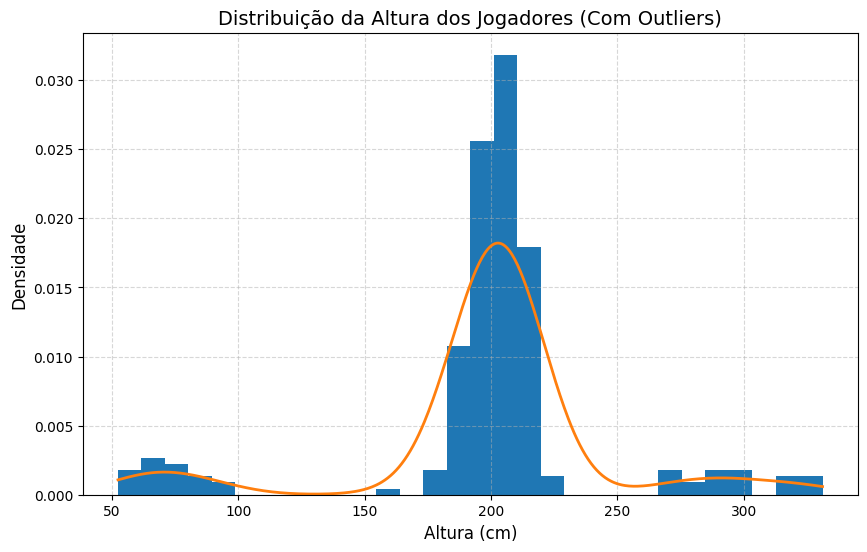

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.figure(figsize=(10,6))

# histograma normal
dados = df_final['player_height']
plt.hist(dados, bins=30, density=True)  # density=True pra encaixar com a curva

# curva de densidade (KDE)
kde = gaussian_kde(dados)
x_vals = np.linspace(dados.min(), dados.max(), 500)
plt.plot(x_vals, kde(x_vals), linewidth=2)

# títulos
plt.title("Distribuição da Altura dos Jogadores (Com Outliers)", fontsize=14)
plt.xlabel("Altura (cm)", fontsize=12)
plt.ylabel("Densidade", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**4 - Detecção de Outliers com Boxplot**

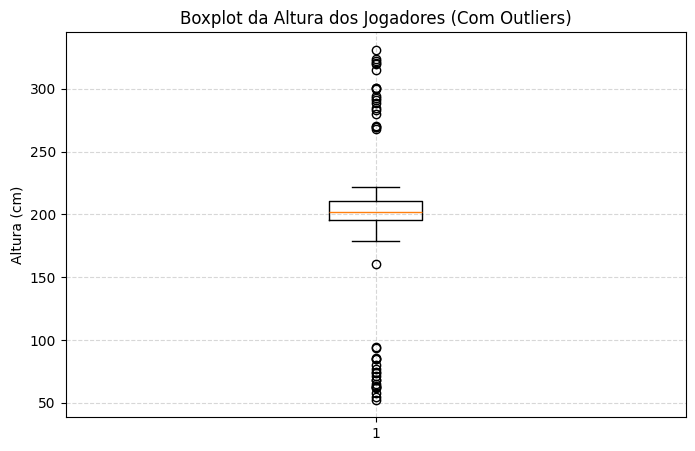

In [8]:
plt.figure(figsize=(8,5))

plt.boxplot(df_final['player_height'])

plt.title("Boxplot da Altura dos Jogadores (Com Outliers)")
plt.ylabel("Altura (cm)")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

 **4.1 dados AIQ**

In [9]:
Q1 = df_final['player_height'].quantile(0.25)
Q3 = df_final['player_height'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print("Limite inferior:", lim_inf)
print("Limite superior:", lim_sup)

Limite inferior: 173.24125000000004
Limite superior: 233.59124999999995


**5 - Eliminação de Outliers**


In [10]:
Q1 = df_final['player_height'].quantile(0.25)
Q3 = df_final['player_height'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df_limpo = df_final[
    (df_final['player_height'] >= lim_inf) &
    (df_final['player_height'] <= lim_sup)
]

print("Removidos:", len(df_final) - len(df_limpo))

Removidos: 41


**6 - Histograma Final (Dados Limpos)**

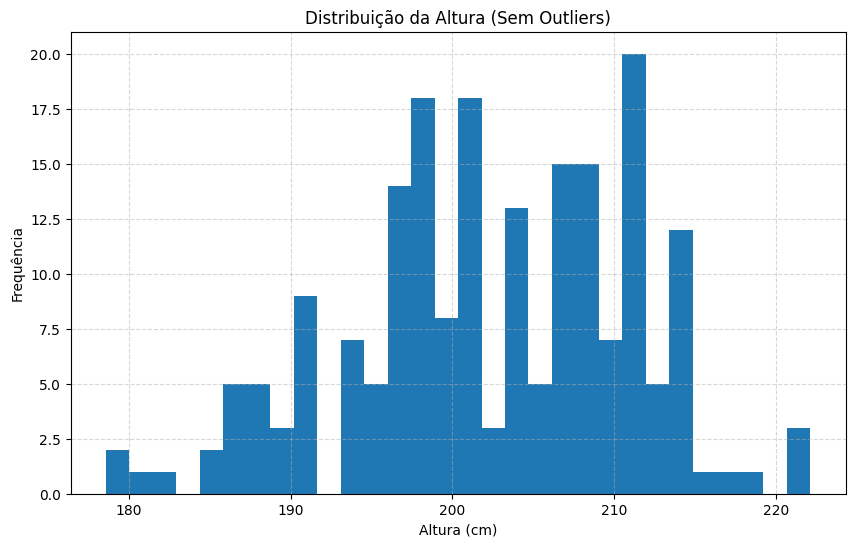

In [11]:
plt.figure(figsize=(10,6))

plt.hist(df_limpo['player_height'], bins=30)

plt.title("Distribuição da Altura (Sem Outliers)")
plt.xlabel("Altura (cm)")
plt.ylabel("Frequência")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**7 - Conclusão**

A análise executada claramente mostrou como a presença de outliers afeta um conjunto de dados reais, fundamentando-se na altura de jogadores da NBA. No início, ao introduzir intencionalmente valores atípicos, observou-se uma alteração considerável na distribuição dos dados, salientada pelo histograma, que exibiu caudas alongadas e uma alteração significante do formato que seria aproximadamente normal.

Com a implementação do método do Intervalo Interquartil (IQR), foi possível determinar os limites inferior e superior que definem os valores que podem ser considerados normais na amostra. Os dados que estavam fora desses limites foram classificados como outliers e, consequentemente, excluídos do conjunto.

Após a exclusão dos outliers, notou-se uma melhoria significativa na distribuição dos dados, que passou a refletir um padrão mais próximo de uma distribuição normal (gaussiana), com uma maior concentração em torno da média e uma redução na dispersão extrema. O histograma resultante destacou essa normalização, tornando os dados mais adequados para análises estatísticas.

Dessa maneira, conclui-se que o método IQR é eficaz e fidedigno para identificar outliers, contribuindo de forma direta para a limpeza e a qualidade dos dados. Contudo, é essencial observar que nem todos os outliers devem ser removidos automaticamente, uma vez que, em certas situações, podem representar informações significativas ou fenômenos reais. Assim, a escolha de retirar ou manter outliers deve sempre levar em conta o contexto da análise.

Em síntese, o tratamento correto de outliers é uma fase essencial na análise de dados, pois aprimora a precisão dos resultados e previne interpretações incorretas.